# Orbit trajectory scatter plots — Frankenstein_He_electron2 (Helium electron 2, softened toy model)

Electron 2 is based on `H_800_1e14` (C=1) but with the Coulomb potential further softened
(aSoft=1.0, up from 1e-6) and the Gaussian sampling widened (sigma=1.0, up from 0.5), to reduce
rescattering and move closer to the SFA limit - plus the higher Shaaran-matched laser intensity
and wider momentum grid. Uses `Frankenstein_He_electron2_softened_traj_export` (a small, fast
CQSFA_fwd run with `exportIndexList` set to 48 final-momentum grid bins - 12 per orbit,
stratified by radius).

Each `Path_Coords_*.dat` file records the full propagated trajectory`(t, r_z, r_perp, r_x, p_z, p_perp, p_x, Sv, Sp, Sso)` for one saddle-point solution.

## Initial momentum, colored by orbit (Frankenstein_He_electron2, 1M-trajectory run)

Same style of plot as the hydrogen notebook, using the full He+ electron-2 "Frankenstein"
dataset for consistency.

Loading to array....
Loaded 51358 points, orbit counts:
orbit
1.0    14477
2.0    16195
3.0    16306
4.0     4380
Name: count, dtype: int64


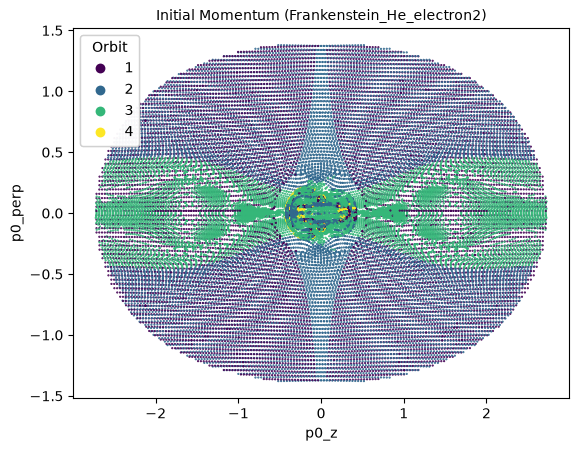

In [14]:
import pandas as pd

HE_DATA_DIR = "/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2_softened_1M/Data"

# Same 15-column format as H_800_1e14 (initCondVars::printVars in CQSFA_fwd/src/initCondsGrid.cpp)
COLUMNS = [
    "p0_z", "p0_perp", "p0_x",
    "t0_re", "t0_im", "z0",
    "pf_z", "pf_perp", "pf_x",
    "orbit",
    "rf_z", "rf_perp", "rf_x",
    "Vmax", "Rmin",
]

print("Loading to array....")
df_he = pd.DataFrame(
    np.loadtxt(f"{HE_DATA_DIR}/Binned_Initial_Condition_Grid_Frankenstein_He_electron2_softened_1M_1e+06.dat"),
    columns=COLUMNS,
)
print(f"Loaded {len(df_he)} points, orbit counts:")
print(df_he["orbit"].value_counts().sort_index())

fig, ax = plt.subplots()
scatter = ax.scatter(df_he["p0_z"], df_he["p0_perp"], c=df_he["orbit"], s=0.3, cmap="viridis")
ax.set_title("Initial Momentum (Frankenstein_He_electron2)", fontsize=10)
ax.set_xlabel("p0_z", fontsize=10)
ax.set_ylabel("p0_perp", fontsize=10)
legend1 = ax.legend(*scatter.legend_elements(), loc="upper left", title="Orbit")
ax.add_artist(legend1)
plt.show()

## Initial vs. final momentum, all orbits (array plot)

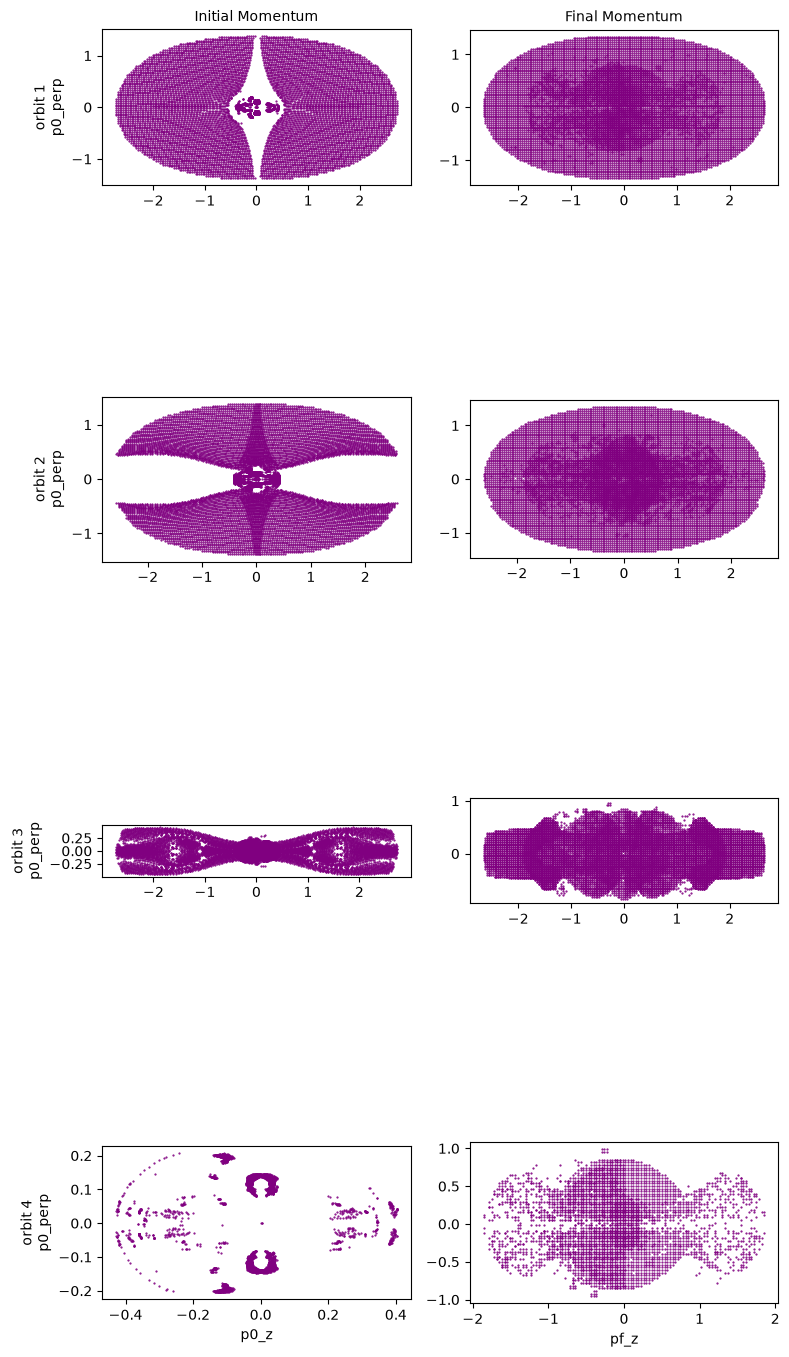

In [15]:
orbits = [1, 2, 3, 4]
fig, axes = plt.subplots(len(orbits), 2, figsize=(8, 4 * len(orbits)))

for row, orbit in enumerate(orbits):
    df_orbit = df_he[df_he["orbit"] == orbit]
    ax1, ax2 = axes[row]

    ax1.scatter(df_orbit["p0_z"], df_orbit["p0_perp"], s=0.3, color="purple")
    ax1.set(adjustable="box", aspect="equal")
    ax1.set_ylabel(f"orbit {orbit}\np0_perp", fontsize=10)
    if row == 0:
        ax1.set_title("Initial Momentum", fontsize=10)

    ax2.scatter(df_orbit["pf_z"], df_orbit["pf_perp"], s=0.3, color="purple")
    ax2.set(adjustable="box", aspect="equal")
    if row == 0:
        ax2.set_title("Final Momentum", fontsize=10)

axes[-1][0].set_xlabel("p0_z", fontsize=10)
axes[-1][1].set_xlabel("pf_z", fontsize=10)
plt.tight_layout()
plt.show()

## Orbit position vs time — which orbits rescatter with the core?

Plotting $r(t)=\sqrt{r_z^2+r_\perp^2}$ shows directly whether a trajectory passes back close
to the parent ion (rescattering) or recedes monotonically (direct, no rescattering). Orbit
classification here follows `initCondsGrid::pointType()` (CQSFA_fwd/src/initCondsGrid.cpp),
confirmed to match Table 1 of Maxwell et al., J. Phys. B 51, 124001 (2018): orb1 = (z0*pf_par
+, pf_perp*p0_perp +), orb2 = (-,+), orb3 = (-,-), orb4 = (+,-).

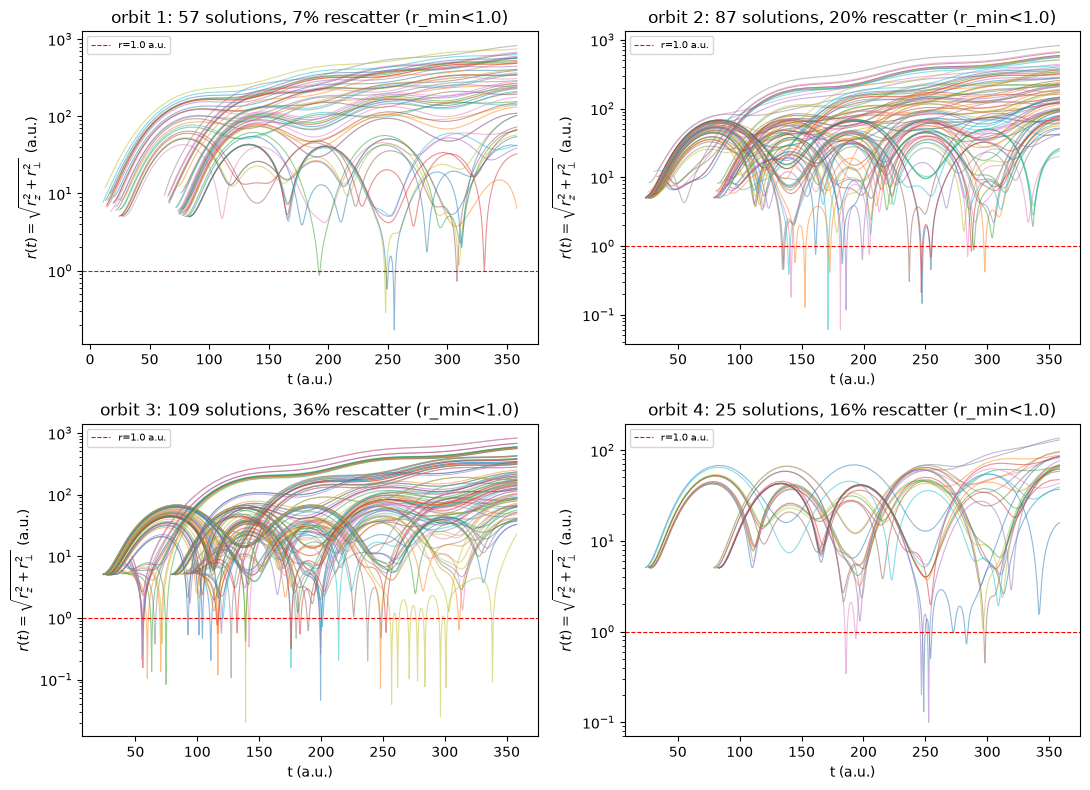

In [16]:
import glob
import numpy as np
import matplotlib.pyplot as plt

TRAJ_DIR = "/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2_softened_traj_export/Data"

# Use EVERY exported solution per orbit (not just a hand-picked few) for a fair statistical
# picture of how often each orbit type actually comes back close to the core.
CORE_THRESHOLD = 1.0  # a.u. - "close approach"/rescattering threshold

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for orb, ax in zip((1, 2, 3, 4), axes.flat):
    files = sorted(glob.glob(f"{TRAJ_DIR}/Path_Coords__*_orb_{orb}_sol_*.dat"))
    r_mins = []
    for fpath in files:
        d = np.loadtxt(fpath)
        if d.ndim != 2 or len(d) < 2:
            continue
        t, rz, rp = d[:, 0], d[:, 1], d[:, 2]
        r = np.hypot(rz, rp)
        r_mins.append(r.min())
        ax.plot(t, r, lw=0.8, alpha=0.5)
    ax.axhline(CORE_THRESHOLD, color="r", lw=0.8, ls="--", label=f"r={CORE_THRESHOLD} a.u.")
    ax.set_yscale("log")
    ax.set_xlabel("t (a.u.)")
    ax.set_ylabel(r"$r(t)=\sqrt{r_z^2+r_\perp^2}$ (a.u.)")
    r_mins = np.array(r_mins)
    frac_rescatter = (r_mins < CORE_THRESHOLD).mean() if len(r_mins) else float("nan")
    ax.set_title(f"orbit {orb}: {len(files)} solutions, {frac_rescatter:.0%} rescatter (r_min<{CORE_THRESHOLD})")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## Same trajectories, but $r_z$ and $r_\perp$ plotted separately

Splitting the radius into its longitudinal (along the laser polarisation) and transverse
components shows whether a close approach to the core happens because the electron returns
along $z$ (typical of field-driven rescattering) or because it passes close in the transverse
plane.

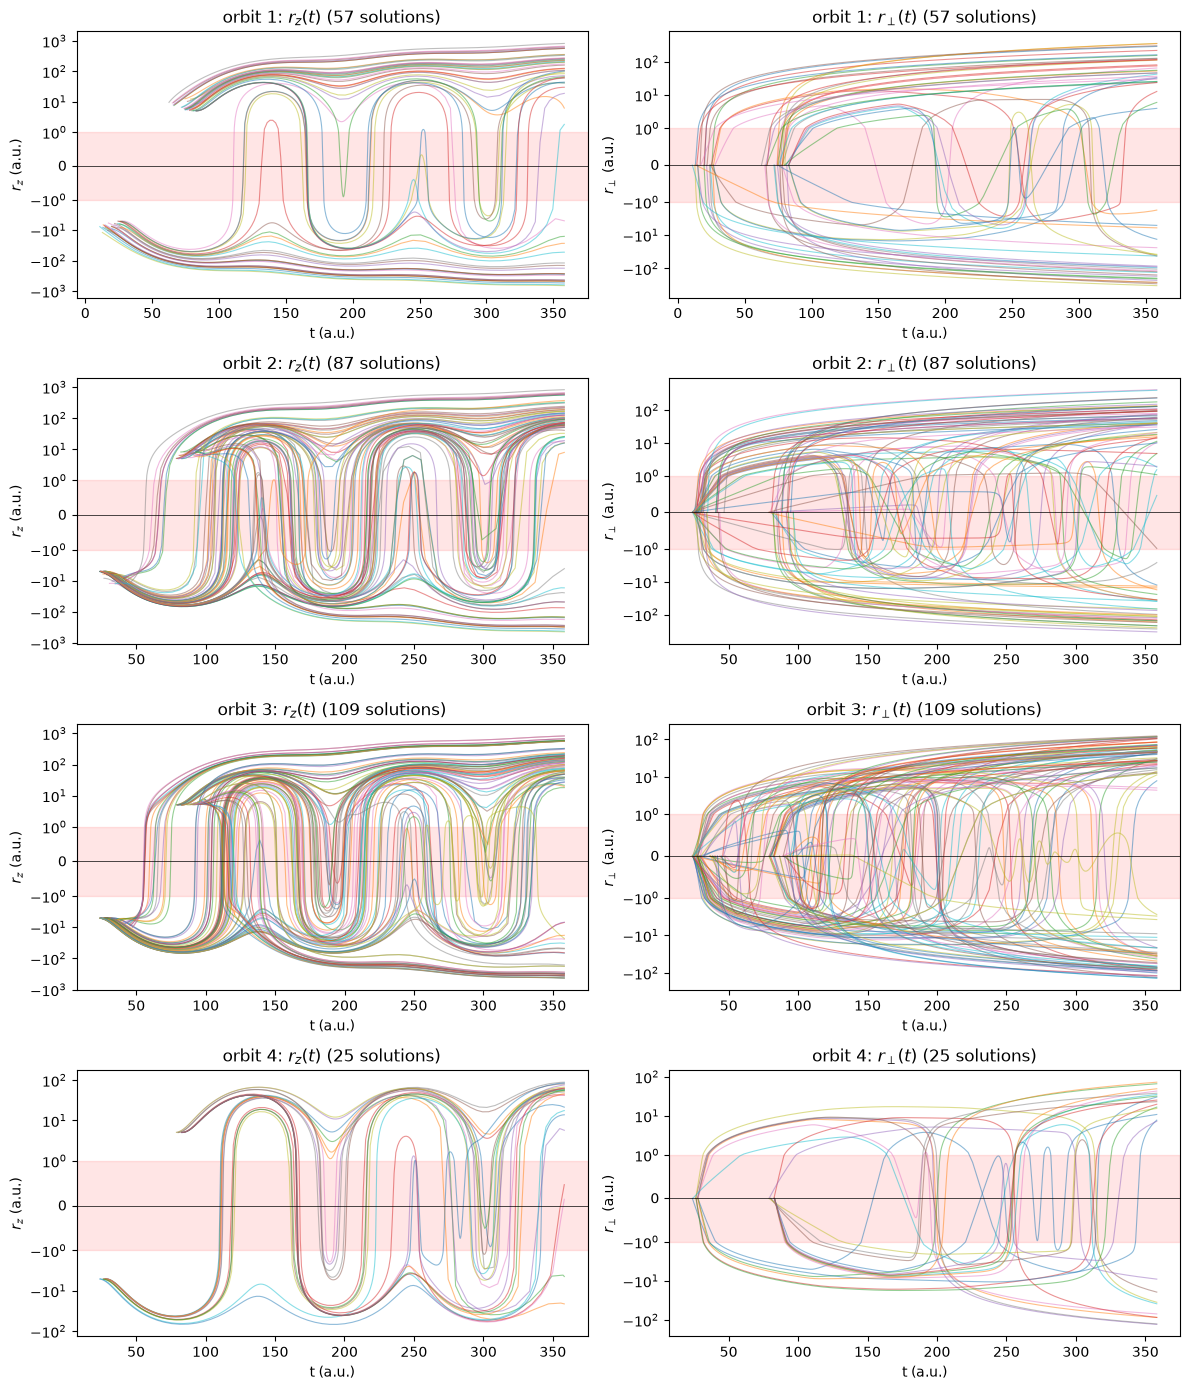

In [17]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14), sharex=False)
for row, orb in enumerate((1, 2, 3, 4)):
    files = sorted(glob.glob(f"{TRAJ_DIR}/Path_Coords__*_orb_{orb}_sol_*.dat"))
    ax_z, ax_p = axes[row]
    for fpath in files:
        d = np.loadtxt(fpath)
        if d.ndim != 2 or len(d) < 2:
            continue
        t, rz, rp = d[:, 0], d[:, 1], d[:, 2]
        ax_z.plot(t, rz, lw=0.8, alpha=0.5)
        ax_p.plot(t, rp, lw=0.8, alpha=0.5)

    for ax, label in ((ax_z, r"$r_z$"), (ax_p, r"$r_\perp$")):
        ax.axhline(0, color="k", lw=0.5)
        ax.axhspan(-CORE_THRESHOLD, CORE_THRESHOLD, color="r", alpha=0.1)
        ax.set_yscale("symlog", linthresh=CORE_THRESHOLD)
        ax.set_xlabel("t (a.u.)")
        ax.set_ylabel(f"{label} (a.u.)")
    ax_z.set_title(f"orbit {orb}: $r_z(t)$ ({len(files)} solutions)")
    ax_p.set_title(f"orbit {orb}: $r_\\perp(t)$ ({len(files)} solutions)")
plt.tight_layout()
plt.show()